# 📊 Speech Enhancement — Step 4: Evaluate Performance

This notebook measures how well the model denoises speech using three standard metrics:

| Metric | What it measures | Range |
|--------|-----------------|-------|
| **SNR** | Signal-to-noise ratio improvement | Higher = better (dB) |
| **PESQ** | Perceptual speech quality (ITU standard) | –0.5 → 4.5, higher = better |
| **STOI** | Speech intelligibility | 0 → 1, higher = better |

### Prerequisites
- Notebooks 01, 02, and 03 completed.
- Drive contains `data/sounds/` QC pairs (clean + noisy) from `create_data()`.
- Drive contains `predictions/` denoised outputs from notebook 03.

In [11]:
# ── 1. Mount Google Drive ──────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted ✓')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted ✓


In [12]:
# ── 2. Install dependencies ────────────────────────────────────────────────
%pip install -q librosa soundfile pesq pystoi

In [ ]:
# ── 3. Clone / pull repo & add src/ to path ────────────────────────────────
import subprocess, sys, os

REPO = 'https://github.com/theweird-kid/speech_enhancement.git'  # <── update
REPO_DIR = '/content/speech_enhancement'

if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone', REPO, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull'], check=True)

sys.path.insert(0, os.path.join(REPO_DIR, 'src'))
print('Repo ready ✓')

Repo ready ✓


In [14]:
# ── 4. Config & imports ────────────────────────────────────────────────────
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import pandas as pd
from pesq import pesq
from pystoi import stoi
import config as C

SR = C.SAMPLE_RATE   # 8000 Hz
print(f'Sample rate: {SR} Hz')
print(f'Sounds dir : {C.SOUND_DIR}')
print(f'Pred dir   : {C.PRED_DIR}')

Sample rate: 8000 Hz
Sounds dir : /content/drive/MyDrive/speech_enhancement/data/sounds
Pred dir   : /content/drive/MyDrive/speech_enhancement/predictions


In [15]:
# ── 5. Helper functions ────────────────────────────────────────────────────

def load_wav(path, sr=SR):
    """Load a WAV and return a float32 array resampled to `sr`."""
    y, _ = librosa.load(path, sr=sr)
    return y.astype(np.float32)

def align(a, b):
    """Trim both arrays to the same length."""
    n = min(len(a), len(b))
    return a[:n], b[:n]

def compute_snr(clean, enhanced):
    noise = clean - enhanced
    return 10 * np.log10(np.sum(clean**2) / (np.sum(noise**2) + 1e-8))

def compute_metrics(clean, test, sr=SR):
    """Return dict of SNR, PESQ, STOI for a (clean, test) pair."""
    c, t = align(clean, test)
    return {
        'SNR (dB)': round(compute_snr(c, t), 3),
        'PESQ'    : round(pesq(sr, c, t, 'nb'), 3),
        'STOI'    : round(stoi(c, t, sr, extended=False), 3),
    }

print('Helpers defined ✓')

Helpers defined ✓


In [16]:
# ── 6. Load QC audio & compute before-metrics ──────────────────────────────
sounds_dir = C.SOUND_DIR

CLEAN_WAV = os.path.join(sounds_dir, 'clean_voice_long.wav')
NOISY_WAV = os.path.join(sounds_dir, 'noisy_voice_long.wav')

clean_full = load_wav(CLEAN_WAV)
noisy_full = load_wav(NOISY_WAV)

# PESQ/STOI are slow on very long audio — evaluate on first 30 seconds
MAX_SECONDS = 30
MAX_SAMPLES = MAX_SECONDS * SR

clean_a = clean_full[:MAX_SAMPLES]
noisy_a = noisy_full[:MAX_SAMPLES]

print(f'Full audio : {len(clean_full)/SR:.1f} s')
print(f'Evaluating on first {MAX_SECONDS}s ({MAX_SAMPLES} samples)')

print('\n=== Noisy vs Clean (before enhancement) ===')
before = compute_metrics(clean_a, noisy_a)
for k, v in before.items():
    print(f'  {k}: {v}')


Full audio : 504.0 s
Evaluating on first 30s (240000 samples)

=== Noisy vs Clean (before enhancement) ===
  SNR (dB): -1.5099999904632568
  PESQ: 1.805
  STOI: 0.783


In [29]:
# ── 7. Load denoised & compute after-metrics ───────────────────────────────
# Run notebook 03 on noisy_voice_long.wav first, save output as:
DENOISED_WAV = os.path.join(C.PRED_DIR, 'denoised_noisy_voice_long.wav')

if os.path.exists(DENOISED_WAV):
    denoised_a = load_wav(DENOISED_WAV)
    print(f'Denoised audio: {len(denoised_a)/SR:.1f} s')

    print('\n=== Denoised vs Clean (after enhancement) ===')
    after = compute_metrics(clean_a, denoised_a)
    for k, v in after.items():
        print(f'  {k}: {v}')

    # Summary table
    import pandas as pd
    metrics = ['SNR (dB)', 'PESQ', 'STOI']
    df = pd.DataFrame({
        'Metric':      metrics,
        'Before':      [before[m] for m in metrics],
        'After':       [after[m]  for m in metrics],
    })
    df['Improvement'] = (df['After'] - df['Before']).round(3)
    print('\n', df.to_string(index=False))
else:
    print(f'[INFO] Not found: {DENOISED_WAV}')
    print('→ Run notebook 03 on noisy_voice_long.wav to generate the denoised file.')


Denoised audio: 504.0 s

=== Denoised vs Clean (after enhancement) ===
  SNR (dB): 2.553999900817871
  PESQ: 1.732
  STOI: 0.744

   Metric  Before  After  Improvement
SNR (dB)  -1.510  2.554        4.064
    PESQ   1.805  1.732       -0.073
    STOI   0.783  0.744       -0.039


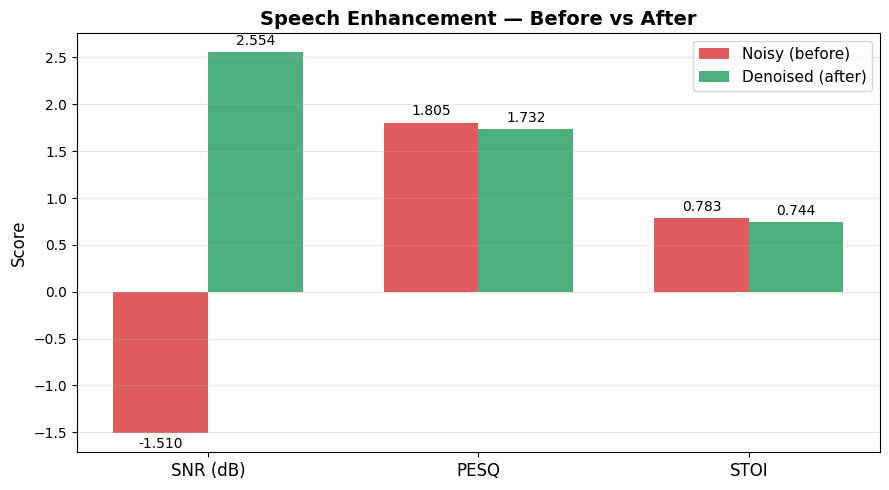

  Metric  Before  After  Improvement
SNR (dB)  -1.510  2.554        4.064
    PESQ   1.805  1.732       -0.073
    STOI   0.783  0.744       -0.039


In [30]:
# ── 8. Bar chart: before vs after ──────────────────────────────────────────
import pandas as pd

# 'after' is only defined if cell 7 found the denoised file
# If not available, we show before-only chart
after = after if 'after' in dir() else {}

metrics     = ['SNR (dB)', 'PESQ', 'STOI']
before_vals = [before[m]       for m in metrics]
after_vals  = [after.get(m, 0) for m in metrics]
has_after   = any(v != 0 for v in after_vals)

x, width = np.arange(len(metrics)), 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2 if has_after else x,
               before_vals, width, label='Noisy (before)', color='#e05c5c')
if has_after:
    bars2 = ax.bar(x + width/2, after_vals, width, label='Denoised (after)', color='#4caf7d')
    ax.bar_label(bars2, fmt='%.3f', padding=3)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Speech Enhancement — Before vs After', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join(C.WEIGHTS_DIR, 'performance_chart.png'), dpi=120)
plt.show()

# Summary table
df_summary = pd.DataFrame({'Metric': metrics, 'Before': before_vals})
if has_after:
    df_summary['After']       = after_vals
    df_summary['Improvement'] = (df_summary['After'] - df_summary['Before']).round(3)
print(df_summary.to_string(index=False))


In [31]:
# ── 9. Skipped — per-sample scatter plot not applicable for long-WAV eval
print("Skipping per-sample plot (single long-WAV evaluation mode)")


Skipping per-sample plot (single long-WAV evaluation mode)


In [33]:
# ── 10. Quick test: before vs after on the long QC audio ───────────────────
CLEAN_WAV    = os.path.join(C.SOUND_DIR, 'clean_voice_long.wav')
NOISY_WAV    = os.path.join(C.SOUND_DIR, 'noisy_voice_long.wav')
DENOISED_WAV = os.path.join(C.PRED_DIR,  'denoised_noisy_voice_long.wav')

# Truncate to 30s — PESQ/STOI are slow on long audio
MAX_SAMPLES = 30 * SR

clean_a    = load_wav(CLEAN_WAV)[:MAX_SAMPLES]
noisy_a    = load_wav(NOISY_WAV)[:MAX_SAMPLES]

print('=== Before enhancement ===')
for k, v in compute_metrics(clean_a, noisy_a).items():
    print(f'  {k}: {v}')

if os.path.exists(DENOISED_WAV):
    denoised_a = load_wav(DENOISED_WAV)[:MAX_SAMPLES]
    print('\n=== After enhancement ===')
    for k, v in compute_metrics(clean_a, denoised_a).items():
        print(f'  {k}: {v}')
else:
    print(f'\n[INFO] Denoised file not found: {DENOISED_WAV}')
    print('→ Run notebook 03 on noisy_voice_long.wav first.')


=== Before enhancement ===
  SNR (dB): -1.5099999904632568
  PESQ: 1.805
  STOI: 0.783

=== After enhancement ===
  SNR (dB): 2.553999900817871
  PESQ: 1.732
  STOI: 0.744


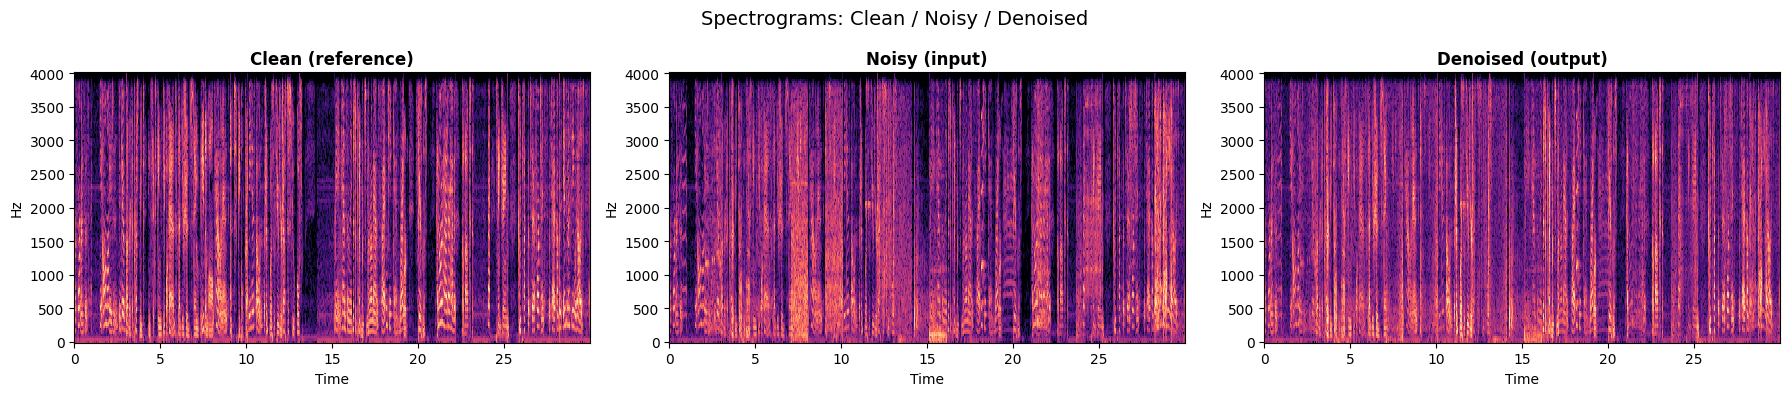

In [34]:
# ── 11. Spectrogram: clean / noisy / denoised side-by-side ────────────────
import librosa.display

def to_spec(audio, n_fft=C.N_FFT, hop=C.HOP_LENGTH_FFT):
    S = librosa.stft(audio, n_fft=n_fft, hop_length=hop)
    return librosa.amplitude_to_db(np.abs(S), ref=np.max)

specs  = [to_spec(clean_a), to_spec(noisy_a), to_spec(denoised_a)]
titles = ['Clean (reference)', 'Noisy (input)', 'Denoised (output)']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, S, title in zip(axes, specs, titles):
    librosa.display.specshow(S, sr=SR, hop_length=C.HOP_LENGTH_FFT,
                             x_axis='time', y_axis='hz', ax=ax, cmap='magma')
    ax.set_title(title, fontsize=12, fontweight='bold')

fig.suptitle('Spectrograms: Clean / Noisy / Denoised', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(C.WEIGHTS_DIR, 'spectrogram_comparison.png'), dpi=120)
plt.show()

In [35]:
# ── 12. Playback ───────────────────────────────────────────────────────────
import IPython.display as ipd

for label, audio in [('🔇 Clean (reference)', clean_a),
                     ('🔊 Noisy (input)',      noisy_a),
                     ('✨ Denoised (output)',  denoised_a)]:
    print(label)
    display(ipd.Audio(audio, rate=SR))

🔇 Clean (reference)


🔊 Noisy (input)


✨ Denoised (output)
